In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sns


In [2]:
data=pd.read_csv("Real estate.csv")

In [3]:
data.head(5)

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [4]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
409    False
410    False
411    False
412    False
413    False
Length: 414, dtype: bool

In [5]:
data=data.drop(columns=['No'])

In [6]:
data.isna().sum()

X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [7]:
x=data[['X1 transaction date','X2 house age','X3 distance to the nearest MRT station','X4 number of convenience stores','X5 latitude']]
y=data[['Y house price of unit area']]

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=40)

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
house_price_predict_area=LinearRegression()

In [12]:
house_price_predict_area.fit(x_train,y_train)

LinearRegression()

In [13]:
y_train_predictor=house_price_predict_area.predict(x_train)

In [14]:
from math import sqrt

In [15]:
from sklearn.metrics import mean_squared_error,r2_score

In [16]:
sqrt(mean_squared_error(y_train,y_train_predictor))

8.829363537807975

In [17]:
r2_score(y_train,y_train_predictor)

0.5920561565997753

In [18]:
y_test_predtictor=house_price_predict_area.predict(x_test)

In [19]:
sqrt(mean_squared_error(y_test,y_test_predtictor))

8.452431245234475

In [20]:
r2_score(y_test,y_test_predtictor)

0.44148736388295506

In [21]:
def house_unit(X1_transaction_date,X2_house_age,X3_distance_to_the_nearest_MRT_station,X4_number_of_convenience_stores,X5_latitude):
    return house_price_predict_area.predict([[X1_transaction_date,X2_house_age,X3_distance_to_the_nearest_MRT_station,X4_number_of_convenience_stores,X5_latitude]])

In [22]:

x1_date = float(input('Enter transaction date'))
x2_age = float(input('Enter house age:'))
x3_mrt = float(input('Enter distance to the nearest MRT station:'))
x4_stores = float(input('Enter number of convenience stores: '))
x5_lat = float(input('Enter latitude:'))
prediction = house_unit(x1_date, x2_age, x3_mrt, x4_stores, x5_lat)
print("\nPredicted House Price of Unit Area:", prediction)


Enter transaction date 4
Enter house age: 5
Enter distance to the nearest MRT station: 5
Enter number of convenience stores:  1
Enter latitude: 5



Predicted House Price of Unit Area: [[-16082.06078787]]


C:\Users\AdminIT\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


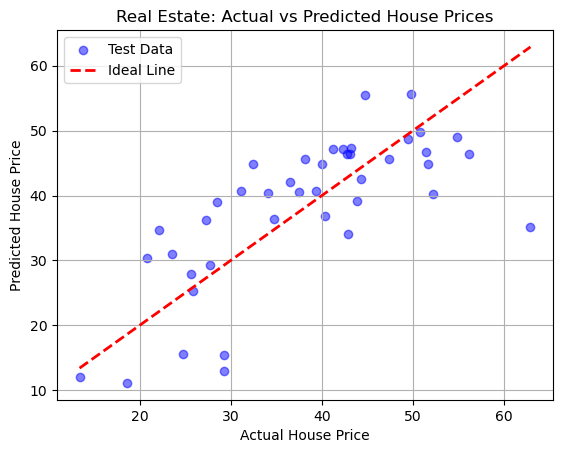

In [23]:
plt.scatter(y_test, y_test_predtictor, color='blue', alpha=0.5, label='Test Data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Ideal Line')

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Real Estate: Actual vs Predicted House Prices')
plt.legend()
plt.grid(True)
plt.show()